In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

X, y = make_regression(
    n_samples=100,
    n_features=5,
    noise=10,
    random_state=42
)

df = pd.DataFrame(
    X,
    columns=["X1", "X2", "X3", "X4", "X5"]
)
df["y"] = y

print(df.info())
print(df.describe())

VX = np.asarray(df[["X1", "X2", "X3", "X4", "X5"]], dtype=np.float32)
Vy = np.asarray(df["y"], dtype=np.float32)

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      100 non-null    float64
 1   X2      100 non-null    float64
 2   X3      100 non-null    float64
 3   X4      100 non-null    float64
 4   X5      100 non-null    float64
 5   y       100 non-null    float64
dtypes: float64(6)
memory usage: 4.8 KB
None
               X1          X2          X3          X4          X5           y
count  100.000000  100.000000  100.000000  100.000000  100.000000  100.000000
mean    -0.032202    0.128058   -0.044747    0.076954   -0.093874    8.740132
std      1.072806    0.959556    0.900352    0.984110    0.983943  140.222531
min     -2.619745   -1.913280   -1.952088   -2.301921   -3.241267 -345.719886
25%     -0.757046   -0.536288   -0.734897   -0.678136   -0.700307  -76.156948
50%     -0.145714    0.152465   -0.010110    0.066421   -0.024662   11.393220
75%      0.648170    

In [ ]:
def hypothesis(Vx, Vw, b):
    return np.dot(Vx, Vw) + b

def cost(Vw, b):
    m = len(VX)
    cost_sum = 0
    for i in range(m):
        Vx = VX[i]
        y = Vy[i]
        y_pred = hypothesis(Vx, Vw, b)
        loss = y_pred - y
        cost_sum += loss ** 2

    return cost_sum / (2 * m)

def compute_gradients(Vw, b, lr):
    m = len(VX)
    dj_dw = np.zeros_like(VX[1])    
    dj_db = 0
    for i in range(m):
        Vx = VX[i]
        y = Vy[i]
        y_pred = hypothesis(Vx, Vw, b)
        loss = y_pred - y
        dj_dw += loss * Vx
        dj_db += loss

    return Vw - ((lr * dj_dw) / m), b - ((lr * dj_db) / m)


np.float32(9478.347)

iteration 0 9431.483
iteration 100 7804.5894
iteration 200 6476.2837
iteration 300 5388.998
iteration 400 4496.708
iteration 500 3762.547
iteration 600 3156.9307
iteration 700 2656.065
iteration 800 2240.7727
iteration 900 1895.5643
iteration 1000 1607.8995
iteration 1100 1367.6045
iteration 1200 1166.4011
iteration 1300 997.5426
iteration 1400 855.5112
iteration 1500 735.7868
iteration 1600 634.6555
iteration 1700 549.0595
iteration 1800 476.47513
iteration 1900 414.80966
iteration 2000 362.33075
iteration 2100 317.59546
iteration 2200 279.40146
iteration 2300 246.74374
iteration 2400 218.78075
iteration 2500 194.80537
iteration 2600 174.2232
iteration 2700 156.53307
iteration 2800 141.31183
iteration 2900 128.20093
iteration 3000 116.89683
iteration 3100 107.1414
iteration 3200 98.71458
iteration 3300 91.43028
iteration 3400 85.12815
iteration 3500 79.672066
iteration 3600 74.9451
iteration 3700 70.84705
iteration 3800 67.292175
iteration 3900 64.2067
iteration 4000 61.527134
iterati

Text(0.5, 1.0, 'Learning Curve')

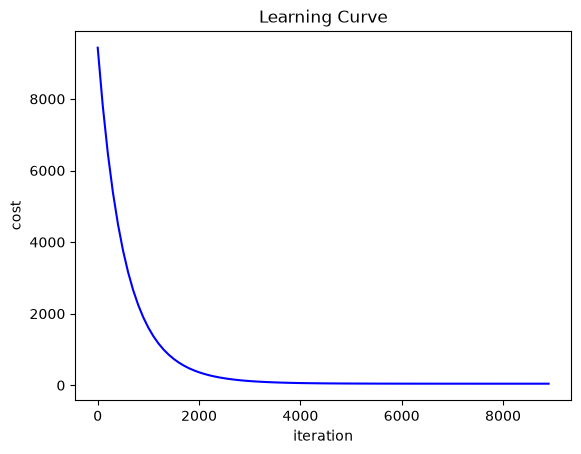

In [43]:
Vw = np.ones_like(VX[0])
b = 10
iteration = 10000
lr = 0.001
initial_cost =  cost(Vw, b)


iter_his = []
cost_his = []

for i in range(iteration):
        new_Vw, new_b = compute_gradients(Vw, b, lr)
        new_cost = cost(new_Vw, new_b)

        if abs(new_cost - initial_cost) < 1e-6:
              break

        if (i % 100 == 0):
            print('iteration', i, new_cost)
            iter_his.append(i)
            cost_his.append(new_cost) 

        initial_cost = new_cost
        Vw, b = new_Vw, new_b

plt.plot(iter_his, cost_his, c='b')
plt.xlabel('iteration')
plt.ylabel('cost')
plt.title('Learning Curve')